<a href="https://www.kaggle.com/code/omborse771924/retail-intelligence-fraud-detection-dataset-eda?scriptVersionId=323068388" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/noopurbhatt/retail-intelligence-fraud-detection-dataset/retail_fraud_detection_100k.csv


## Load Dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/noopurbhatt/retail-intelligence-fraud-detection-dataset/retail_fraud_detection_100k.csv')

In [3]:
df.head()

,transaction_id,customer_id,transaction_timestamp,transaction_amount,payment_method,device_type,location,merchant_category,is_international,transaction_frequency_24h,...,failed_transaction_count_24h,account_age_days,previous_fraud_flag,unusual_amount_flag,unusual_location_flag,multiple_transactions_short_time,high_risk_device_flag,velocity_flag,fraud_flag,fraud_risk
0,T0000001,C20953,2026-03-04 19:56:23.679173,56.31,Debit Card,Tablet,Canada,Fashion,0,13,...,4,1054,0,0,0,1,0,1,0,Medium
1,T0000002,C24133,2026-03-09 19:56:23.679330,20.35,Credit Card,Tablet,India,Electronics,0,3,...,2,97,0,0,0,0,0,0,0,Low
2,T0000003,C07165,2026-01-01 19:56:23.679362,48.72,Debit Card,Tablet,UK,Travel,0,8,...,4,779,1,0,0,0,0,0,0,Medium
3,T0000004,C19310,2025-12-09 19:56:23.679385,153.62,Debit Card,Mobile,Australia,Fashion,0,14,...,3,286,1,1,0,1,0,1,1,High
4,T0000005,C25019,2025-11-09 19:56:23.679409,115.32,PayPal,Mobile,India,Gaming,0,10,...,3,866,0,0,0,1,0,0,0,Low


In [4]:
df.tail()

,transaction_id,customer_id,transaction_timestamp,transaction_amount,payment_method,device_type,location,merchant_category,is_international,transaction_frequency_24h,...,failed_transaction_count_24h,account_age_days,previous_fraud_flag,unusual_amount_flag,unusual_location_flag,multiple_transactions_short_time,high_risk_device_flag,velocity_flag,fraud_flag,fraud_risk
99995,T0099996,C06953,2026-01-01 19:56:25.768931,79.72,Credit Card,Mobile,Australia,Travel,0,1,...,0,990,0,0,0,0,0,0,0,Low
99996,T0099997,C06691,2026-01-25 19:56:25.768949,8.09,PayPal,Desktop,Australia,Luxury,0,2,...,1,1438,1,0,0,0,0,0,0,Low
99997,T0099998,C16351,2025-09-24 19:56:25.768970,94.69,Debit Card,Desktop,Australia,Groceries,1,12,...,3,532,0,0,1,1,0,1,1,Medium
99998,T0099999,C22185,2026-03-06 19:56:25.768990,63.31,Google Pay,Tablet,Australia,Travel,0,9,...,4,556,1,0,0,1,0,0,1,Medium
99999,T0100000,C08043,2025-10-24 19:56:25.769007,37.45,Apple Pay,Desktop,Germany,Travel,1,10,...,2,688,1,0,1,1,0,0,1,Medium


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 21 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   transaction_id                    100000 non-null  object 
 1   customer_id                       100000 non-null  object 
 2   transaction_timestamp             100000 non-null  object 
 3   transaction_amount                100000 non-null  float64
 4   payment_method                    100000 non-null  object 
 5   device_type                       100000 non-null  object 
 6   location                          100000 non-null  object 
 7   merchant_category                 100000 non-null  object 
 8   is_international                  100000 non-null  int64  
 9   transaction_frequency_24h         100000 non-null  int64  
 10  avg_transaction_amount_7d         100000 non-null  float64
 11  failed_transaction_count_24h      100000 non-null  in

In [6]:
df.describe()

,transaction_amount,is_international,transaction_frequency_24h,avg_transaction_amount_7d,failed_transaction_count_24h,account_age_days,previous_fraud_flag,unusual_amount_flag,unusual_location_flag,multiple_transactions_short_time,high_risk_device_flag,velocity_flag,fraud_flag
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,120.475407,0.498010,7.489910,109.810966,2.003560,1005.329380,0.500150,0.229530,0.498010,0.427040,0.100960,0.283980,0.475080
std,119.787252,0.499999,4.024028,51.892854,1.414923,573.313726,0.500002,0.420533,0.499999,0.494651,0.301277,0.450929,0.499381
min,0.000000,0.000000,1.000000,20.000000,0.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,34.820000,0.000000,4.000000,64.910000,1.000000,510.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,84.130000,0.000000,7.000000,109.780000,2.000000,1004.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,167.520000,1.000000,11.000000,154.672500,3.000000,1501.250000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000
max,1548.520000,1.000000,14.000000,200.000000,4.000000,1999.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [7]:
df.isnull()

,transaction_id,customer_id,transaction_timestamp,transaction_amount,payment_method,device_type,location,merchant_category,is_international,transaction_frequency_24h,...,failed_transaction_count_24h,account_age_days,previous_fraud_flag,unusual_amount_flag,unusual_location_flag,multiple_transactions_short_time,high_risk_device_flag,velocity_flag,fraud_flag,fraud_risk
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
99996,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
99997,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
99998,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [8]:
df.isnull().sum()

transaction_id                      0
customer_id                         0
transaction_timestamp               0
transaction_amount                  0
payment_method                      0
device_type                         0
location                            0
merchant_category                   0
is_international                    0
transaction_frequency_24h           0
avg_transaction_amount_7d           0
failed_transaction_count_24h        0
account_age_days                    0
previous_fraud_flag                 0
unusual_amount_flag                 0
unusual_location_flag               0
multiple_transactions_short_time    0
high_risk_device_flag               0
velocity_flag                       0
fraud_flag                          0
fraud_risk                          0
dtype: int64

In [9]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
99995    False
99996    False
99997    False
99998    False
99999    False
Length: 100000, dtype: bool

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.columns

Index(['transaction_id', 'customer_id', 'transaction_timestamp',
       'transaction_amount', 'payment_method', 'device_type', 'location',
       'merchant_category', 'is_international', 'transaction_frequency_24h',
       'avg_transaction_amount_7d', 'failed_transaction_count_24h',
       'account_age_days', 'previous_fraud_flag', 'unusual_amount_flag',
       'unusual_location_flag', 'multiple_transactions_short_time',
       'high_risk_device_flag', 'velocity_flag', 'fraud_flag', 'fraud_risk'],
      dtype='object')

## EDA

Dataset Shape: (100000, 21)

Columns:
['transaction_id', 'customer_id', 'transaction_timestamp', 'transaction_amount', 'payment_method', 'device_type', 'location', 'merchant_category', 'is_international', 'transaction_frequency_24h', 'avg_transaction_amount_7d', 'failed_transaction_count_24h', 'account_age_days', 'previous_fraud_flag', 'unusual_amount_flag', 'unusual_location_flag', 'multiple_transactions_short_time', 'high_risk_device_flag', 'velocity_flag', 'fraud_flag', 'fraud_risk']

First 5 Rows:


,transaction_id,customer_id,transaction_timestamp,transaction_amount,payment_method,device_type,location,merchant_category,is_international,transaction_frequency_24h,...,failed_transaction_count_24h,account_age_days,previous_fraud_flag,unusual_amount_flag,unusual_location_flag,multiple_transactions_short_time,high_risk_device_flag,velocity_flag,fraud_flag,fraud_risk
0,T0000001,C20953,2026-03-04 19:56:23.679173,56.31,Debit Card,Tablet,Canada,Fashion,0,13,...,4,1054,0,0,0,1,0,1,0,Medium
1,T0000002,C24133,2026-03-09 19:56:23.679330,20.35,Credit Card,Tablet,India,Electronics,0,3,...,2,97,0,0,0,0,0,0,0,Low
2,T0000003,C07165,2026-01-01 19:56:23.679362,48.72,Debit Card,Tablet,UK,Travel,0,8,...,4,779,1,0,0,0,0,0,0,Medium
3,T0000004,C19310,2025-12-09 19:56:23.679385,153.62,Debit Card,Mobile,Australia,Fashion,0,14,...,3,286,1,1,0,1,0,1,1,High
4,T0000005,C25019,2025-11-09 19:56:23.679409,115.32,PayPal,Mobile,India,Gaming,0,10,...,3,866,0,0,0,1,0,0,0,Low



Missing Values:
transaction_id                      0
customer_id                         0
transaction_timestamp               0
transaction_amount                  0
payment_method                      0
device_type                         0
location                            0
merchant_category                   0
is_international                    0
transaction_frequency_24h           0
avg_transaction_amount_7d           0
failed_transaction_count_24h        0
account_age_days                    0
previous_fraud_flag                 0
unusual_amount_flag                 0
unusual_location_flag               0
multiple_transactions_short_time    0
high_risk_device_flag               0
velocity_flag                       0
fraud_flag                          0
fraud_risk                          0
dtype: int64


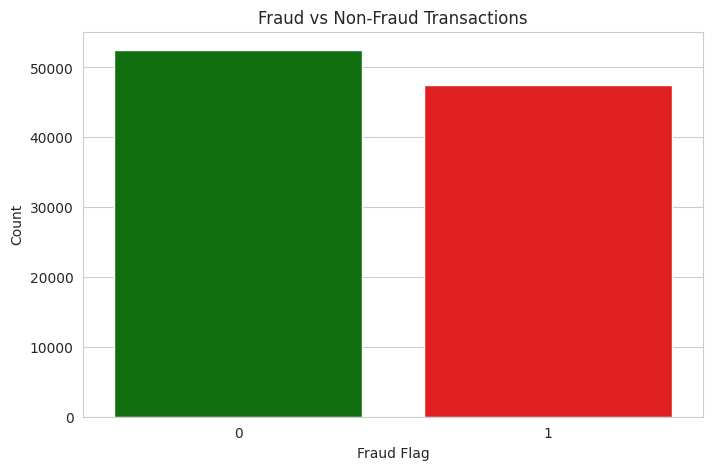

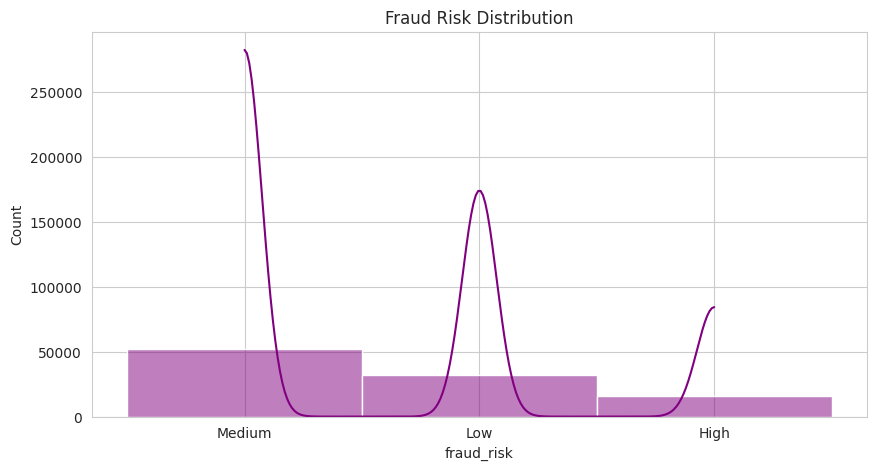

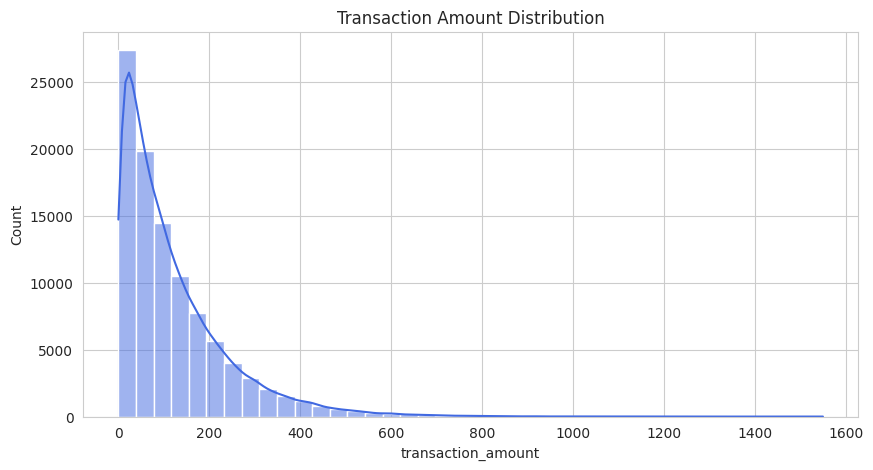

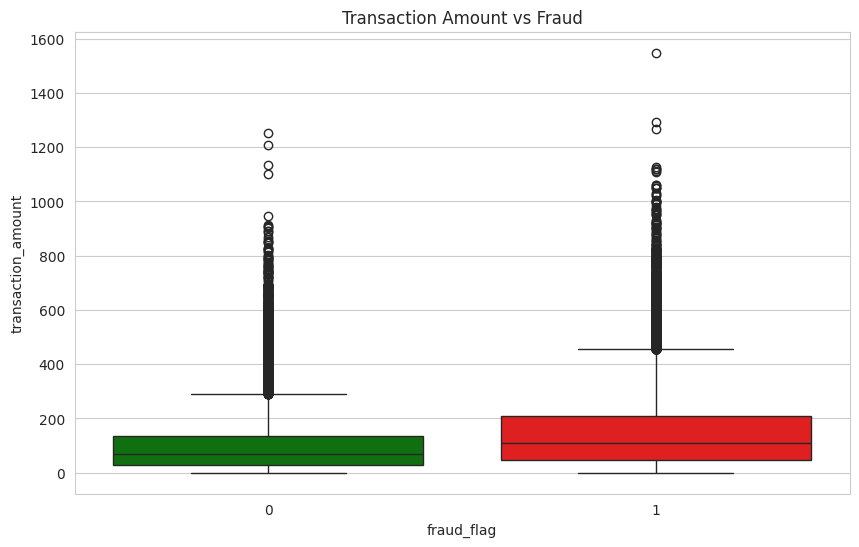

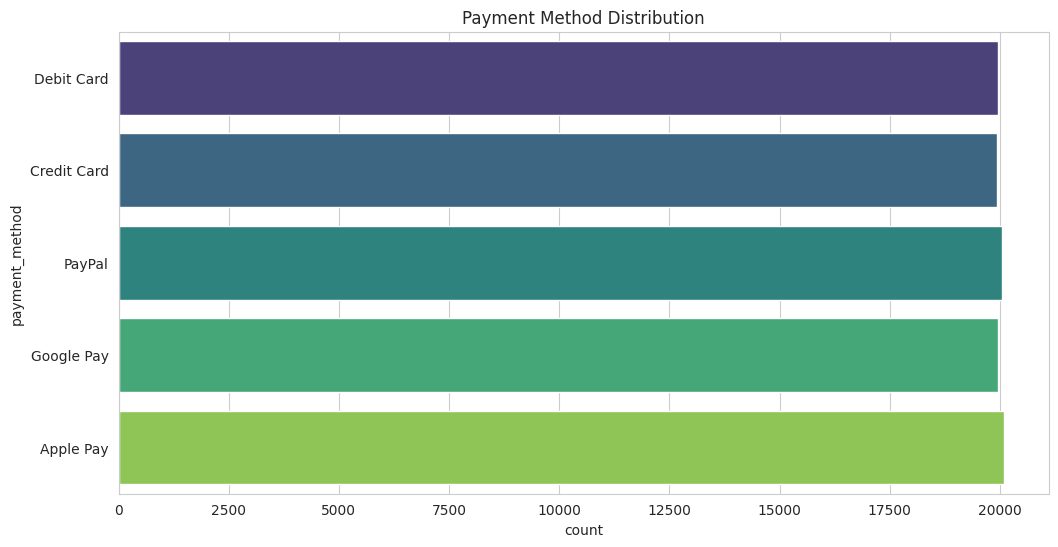

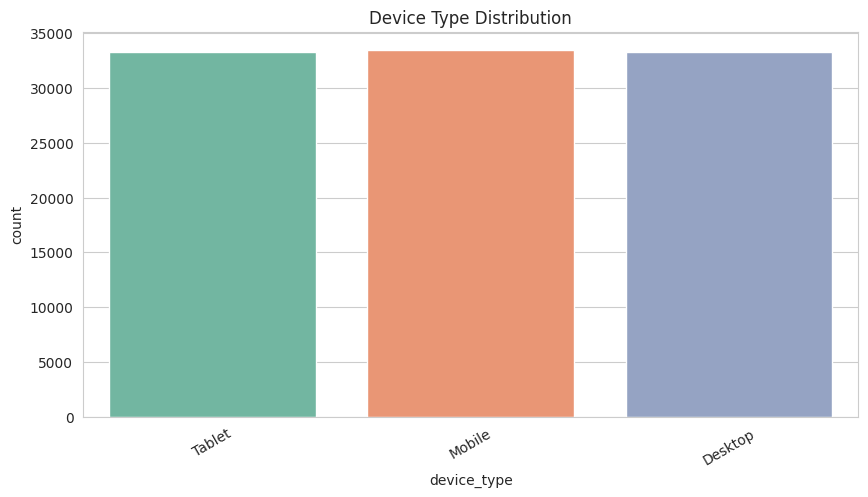

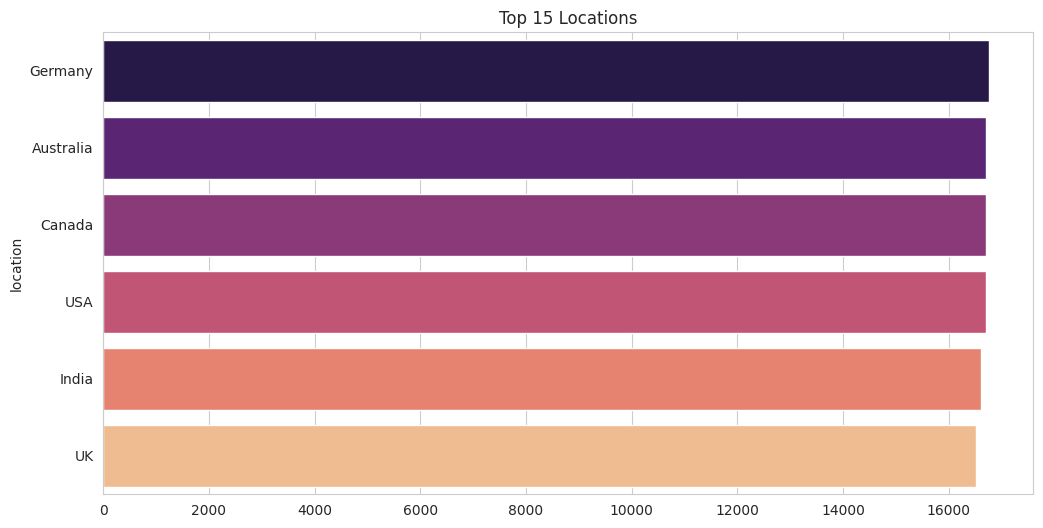

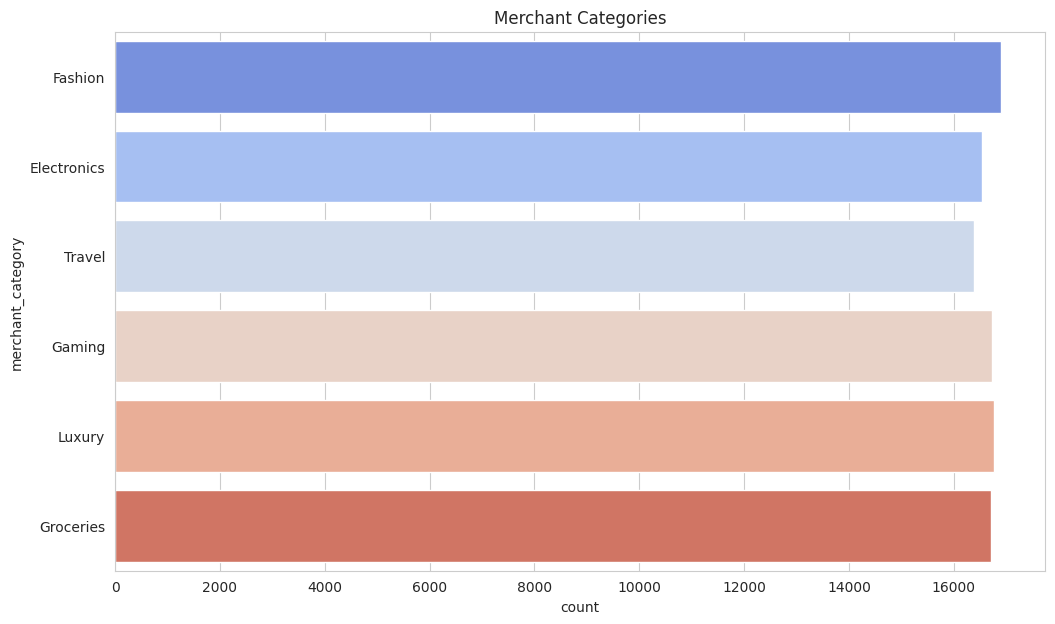

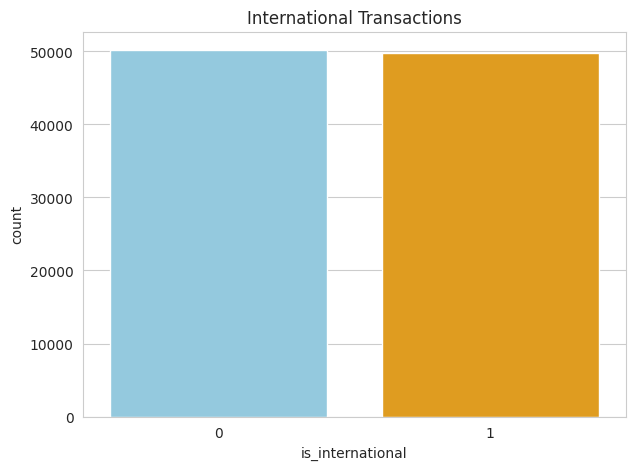

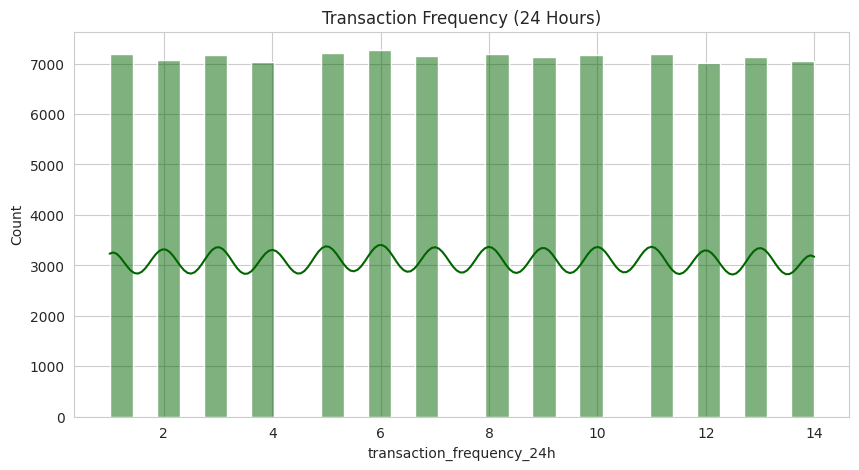

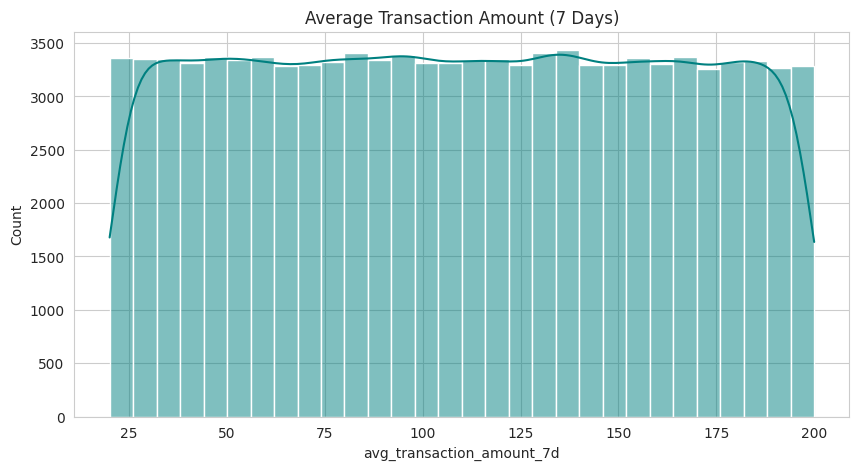

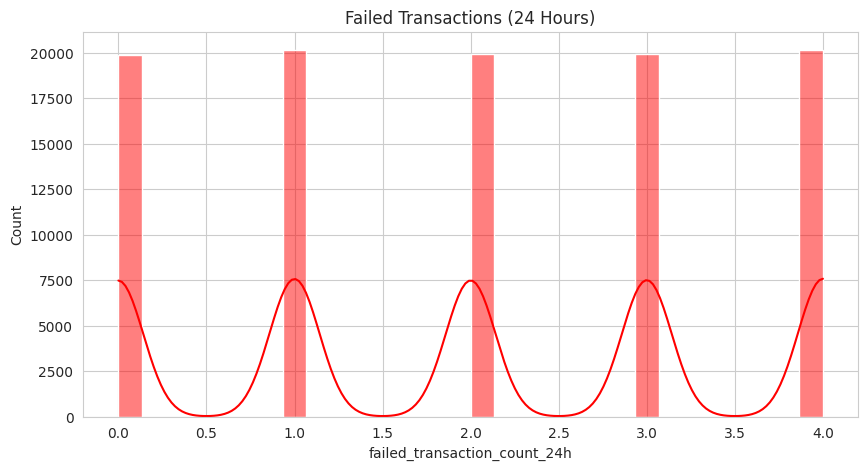

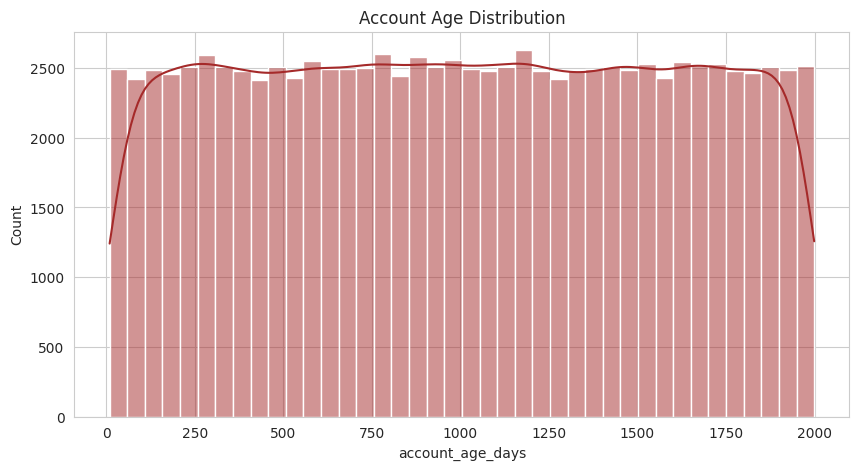

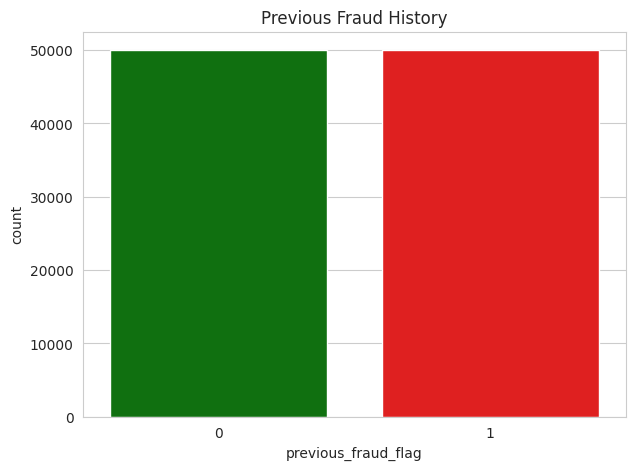

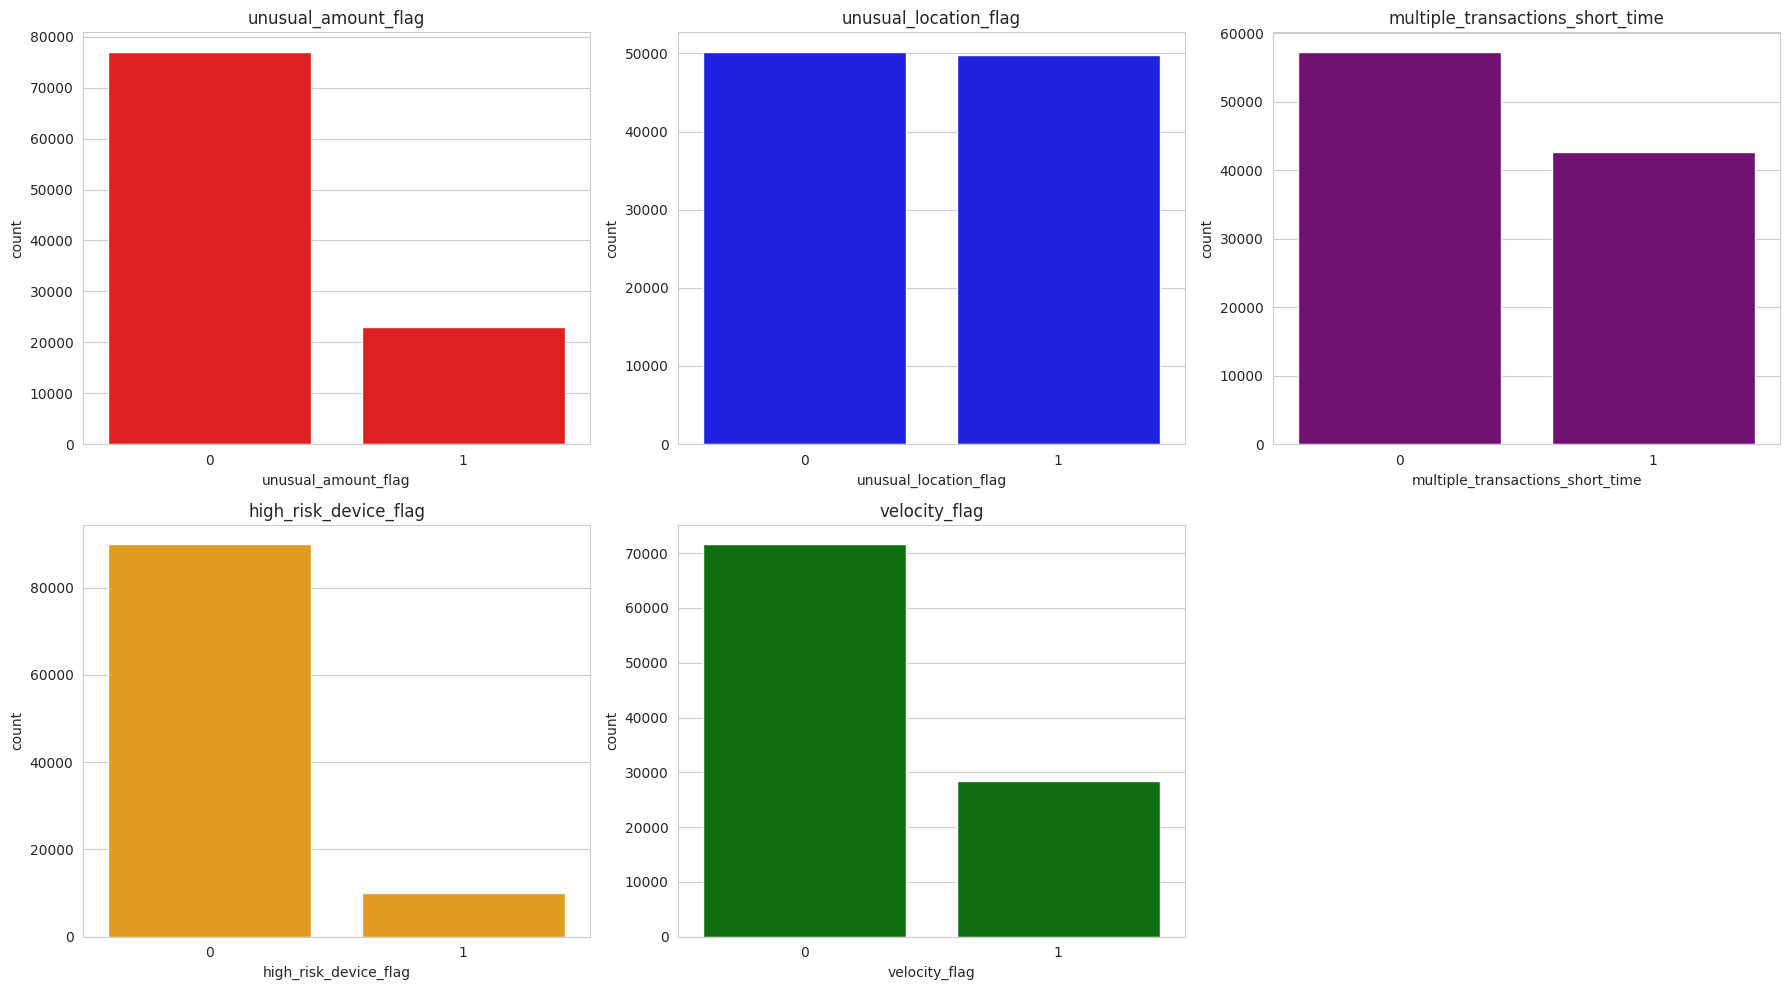

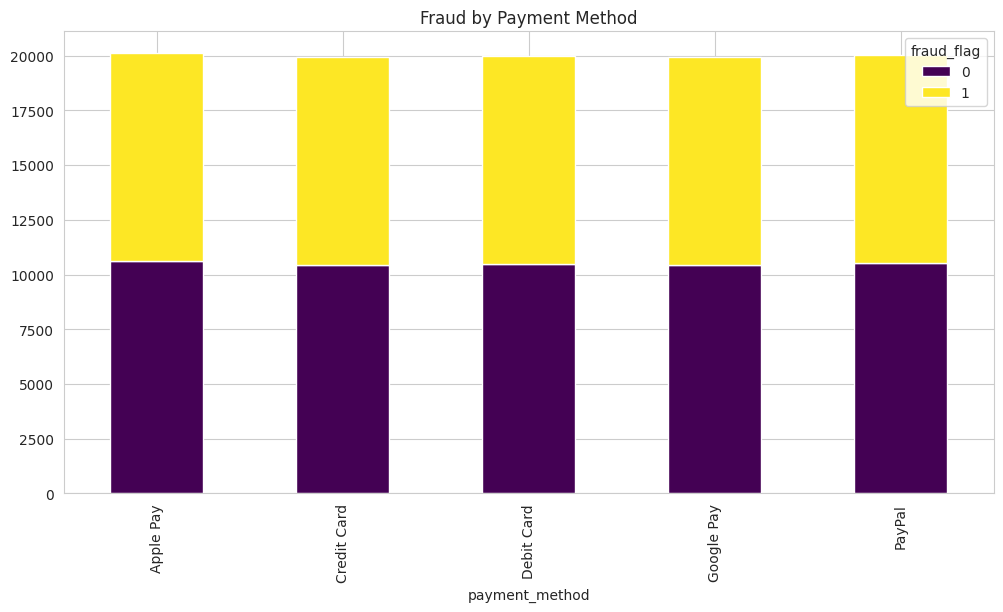

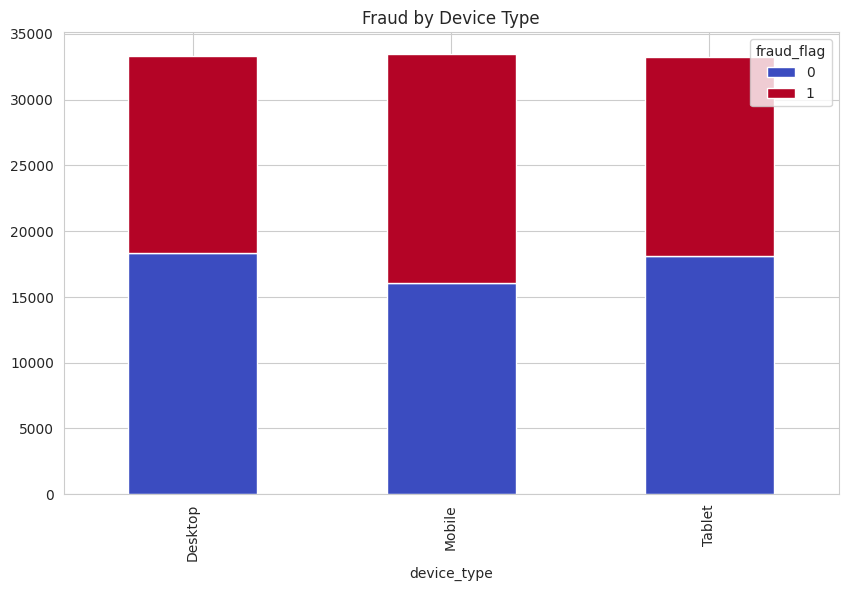

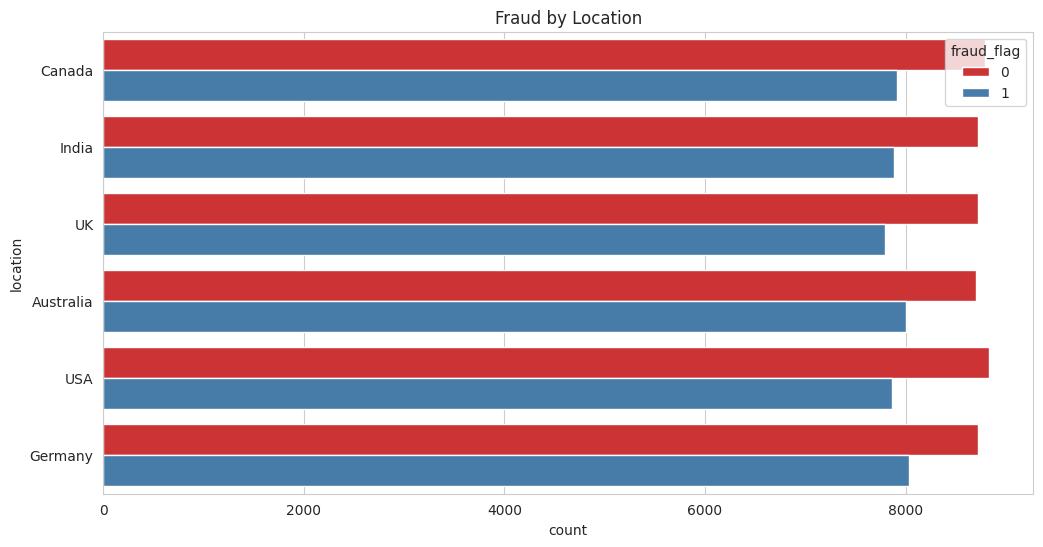

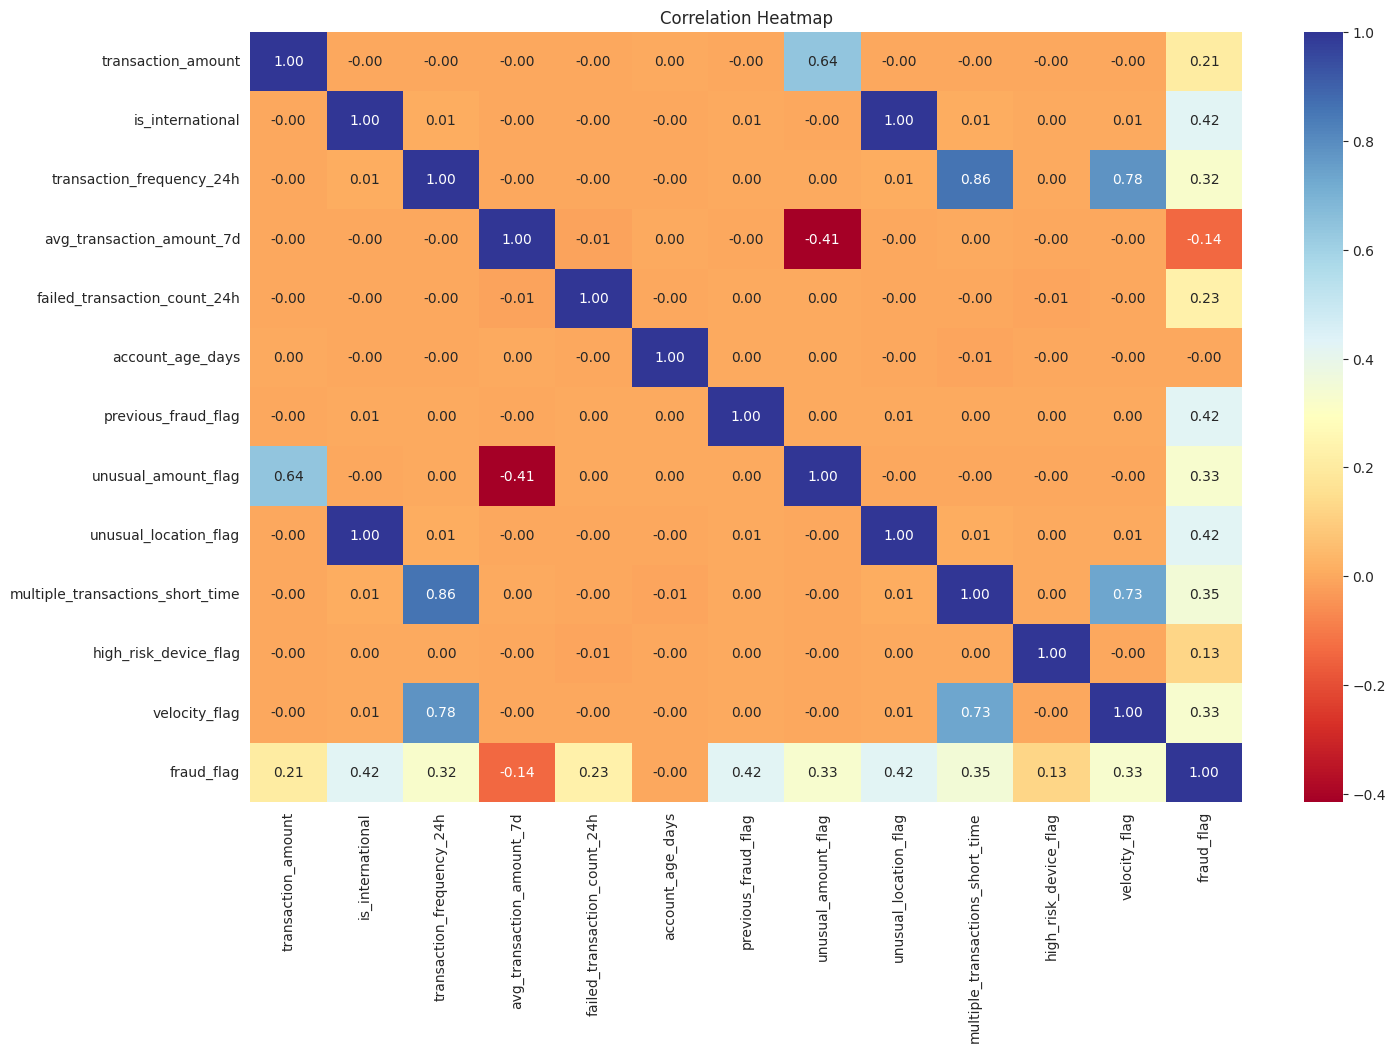

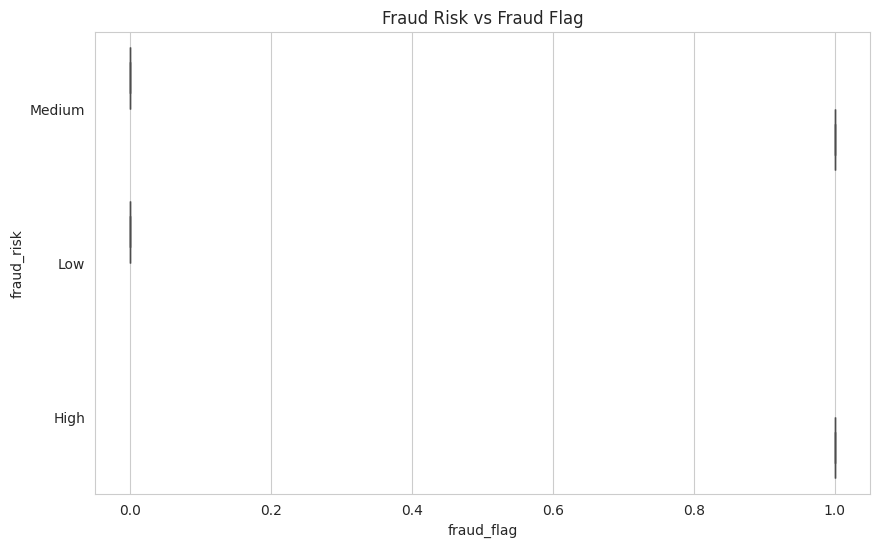

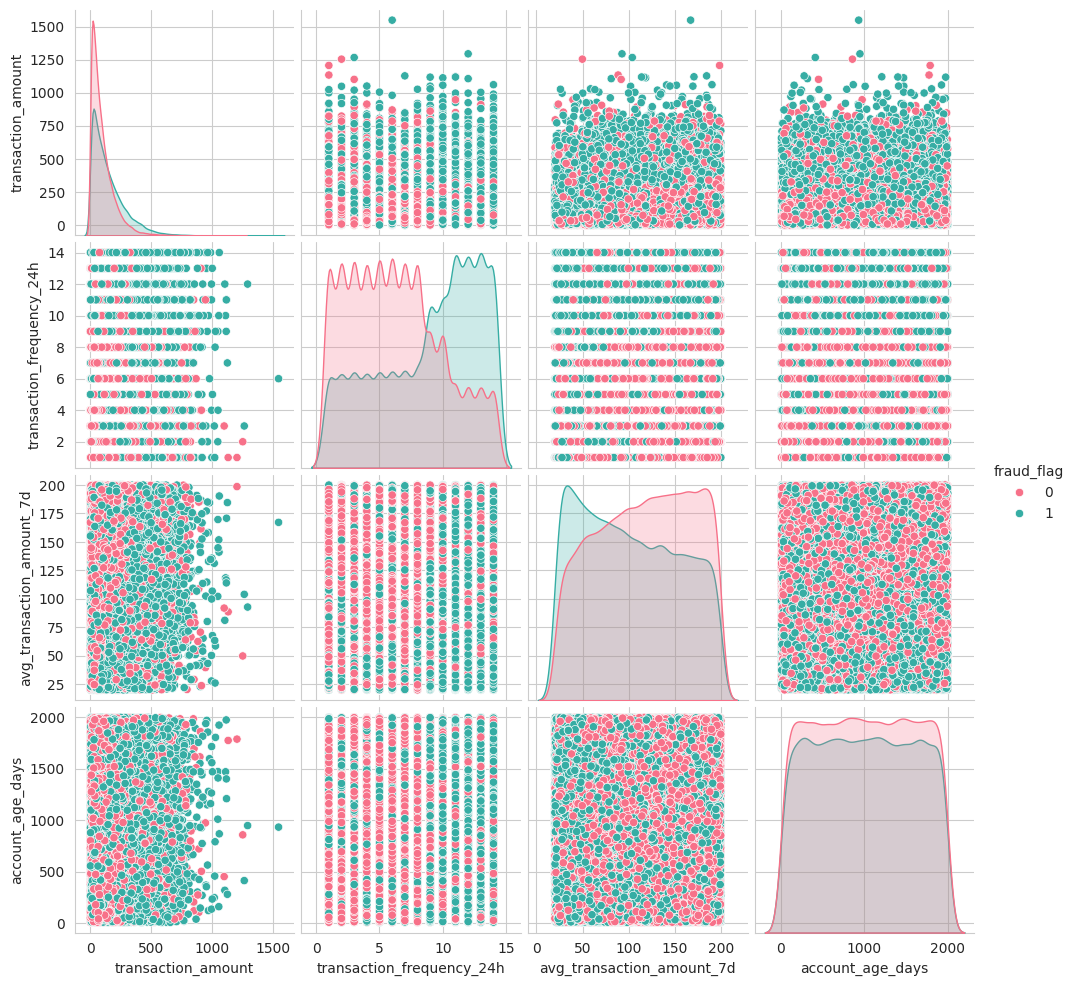


Fraud Percentage:
fraud_flag
0    52.492
1    47.508
Name: proportion, dtype: float64

Visualization Completed Successfully


In [12]:
# ==========================================================
# FRAUD DETECTION DATASET - COMPLETE VISUALIZATION
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================================
# BASIC INFORMATION
# ==========================================================

print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

print("\nMissing Values:")
print(df.isnull().sum())

# ==========================================================
# STYLE SETTINGS
# ==========================================================

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

# ==========================================================
# TARGET VARIABLE DISTRIBUTION
# ==========================================================

plt.figure(figsize=(8,5))

sns.countplot(
    x='fraud_flag',
    data=df,
    hue='fraud_flag',
    palette=['green','red'],
    legend=False
)

plt.title('Fraud vs Non-Fraud Transactions')
plt.xlabel('Fraud Flag')
plt.ylabel('Count')

plt.show()

# ==========================================================
# FRAUD RISK DISTRIBUTION
# ==========================================================

plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x='fraud_risk',
    bins=30,
    kde=True,
    color='purple'
)

plt.title('Fraud Risk Distribution')

plt.show()

# ==========================================================
# TRANSACTION AMOUNT DISTRIBUTION
# ==========================================================

plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x='transaction_amount',
    bins=40,
    kde=True,
    color='royalblue'
)

plt.title('Transaction Amount Distribution')

plt.show()

# ==========================================================
# TRANSACTION AMOUNT VS FRAUD
# ==========================================================

plt.figure(figsize=(10,6))

sns.boxplot(
    x='fraud_flag',
    y='transaction_amount',
    data=df,
    hue='fraud_flag',
    palette=['green','red'],
    legend=False
)

plt.title('Transaction Amount vs Fraud')

plt.show()

# ==========================================================
# PAYMENT METHOD DISTRIBUTION
# ==========================================================

plt.figure(figsize=(12,6))

sns.countplot(
    y='payment_method',
    data=df,
    hue='payment_method',
    palette='viridis',
    legend=False
)

plt.title('Payment Method Distribution')

plt.show()

# ==========================================================
# DEVICE TYPE DISTRIBUTION
# ==========================================================

plt.figure(figsize=(10,5))

sns.countplot(
    x='device_type',
    data=df,
    hue='device_type',
    palette='Set2',
    legend=False
)

plt.title('Device Type Distribution')

plt.xticks(rotation=30)

plt.show()

# ==========================================================
# TOP LOCATIONS
# ==========================================================

top_locations = df['location'].value_counts().head(15)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_locations.values,
    y=top_locations.index,
    hue=top_locations.index,
    palette='magma',
    legend=False
)

plt.title('Top 15 Locations')

plt.show()

# ==========================================================
# MERCHANT CATEGORY
# ==========================================================

plt.figure(figsize=(12,7))

sns.countplot(
    y='merchant_category',
    data=df,
    hue='merchant_category',
    palette='coolwarm',
    legend=False
)

plt.title('Merchant Categories')

plt.show()

# ==========================================================
# INTERNATIONAL TRANSACTIONS
# ==========================================================

plt.figure(figsize=(7,5))

sns.countplot(
    x='is_international',
    data=df,
    hue='is_international',
    palette=['skyblue','orange'],
    legend=False
)

plt.title('International Transactions')

plt.show()

# ==========================================================
# TRANSACTION FREQUENCY
# ==========================================================

plt.figure(figsize=(10,5))

sns.histplot(
    df['transaction_frequency_24h'],
    bins=30,
    kde=True,
    color='darkgreen'
)

plt.title('Transaction Frequency (24 Hours)')

plt.show()

# ==========================================================
# AVG TRANSACTION AMOUNT 7 DAYS
# ==========================================================

plt.figure(figsize=(10,5))

sns.histplot(
    df['avg_transaction_amount_7d'],
    bins=30,
    kde=True,
    color='teal'
)

plt.title('Average Transaction Amount (7 Days)')

plt.show()

# ==========================================================
# FAILED TRANSACTION COUNT
# ==========================================================

plt.figure(figsize=(10,5))

sns.histplot(
    df['failed_transaction_count_24h'],
    bins=30,
    kde=True,
    color='red'
)

plt.title('Failed Transactions (24 Hours)')

plt.show()

# ==========================================================
# ACCOUNT AGE
# ==========================================================

plt.figure(figsize=(10,5))

sns.histplot(
    df['account_age_days'],
    bins=40,
    kde=True,
    color='brown'
)

plt.title('Account Age Distribution')

plt.show()

# ==========================================================
# PREVIOUS FRAUD FLAG
# ==========================================================

plt.figure(figsize=(7,5))

sns.countplot(
    x='previous_fraud_flag',
    data=df,
    hue='previous_fraud_flag',
    palette=['green','red'],
    legend=False
)

plt.title('Previous Fraud History')

plt.show()

# ==========================================================
# RISK FLAGS
# ==========================================================

risk_flags = [
    'unusual_amount_flag',
    'unusual_location_flag',
    'multiple_transactions_short_time',
    'high_risk_device_flag',
    'velocity_flag'
]

fig, axes = plt.subplots(2,3, figsize=(18,10))

colors = ['red','blue','purple','orange','green']

for i, col in enumerate(risk_flags):

    sns.countplot(
        x=col,
        data=df,
        color=colors[i],
        ax=axes[i//3, i%3]
    )

    axes[i//3, i%3].set_title(col)

axes[1,2].axis('off')

plt.tight_layout()
plt.show()

# ==========================================================
# FRAUD RATE BY PAYMENT METHOD
# ==========================================================

payment_fraud = pd.crosstab(
    df['payment_method'],
    df['fraud_flag']
)

payment_fraud.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6),
    colormap='viridis'
)

plt.title('Fraud by Payment Method')

plt.show()

# ==========================================================
# FRAUD RATE BY DEVICE TYPE
# ==========================================================

device_fraud = pd.crosstab(
    df['device_type'],
    df['fraud_flag']
)

device_fraud.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6),
    colormap='coolwarm'
)

plt.title('Fraud by Device Type')

plt.show()

# ==========================================================
# FRAUD RATE BY LOCATION
# ==========================================================

top_loc = df['location'].value_counts().head(10).index

temp = df[df['location'].isin(top_loc)]

plt.figure(figsize=(12,6))

sns.countplot(
    y='location',
    hue='fraud_flag',
    data=temp,
    palette='Set1'
)

plt.title('Fraud by Location')

plt.show()

# ==========================================================
# CORRELATION HEATMAP
# ==========================================================

numeric_cols = df.select_dtypes(
    include=['int64','float64']
).columns

plt.figure(figsize=(16,10))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap='RdYlBu',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

# ==========================================================
# FRAUD RISK VS FRAUD FLAG
# ==========================================================

plt.figure(figsize=(10,6))

sns.boxplot(
    x='fraud_flag',
    y='fraud_risk',
    data=df,
    hue='fraud_flag',
    palette=['blue','red'],
    legend=False
)

plt.title('Fraud Risk vs Fraud Flag')

plt.show()

# ==========================================================
# PAIRPLOT
# ==========================================================

important_features = [
    'transaction_amount',
    'transaction_frequency_24h',
    'avg_transaction_amount_7d',
    'account_age_days',
    'fraud_risk',
    'fraud_flag'
]

sns.pairplot(
    df[important_features],
    hue='fraud_flag',
    palette='husl'
)

plt.show()

# ==========================================================
# FRAUD PERCENTAGE
# ==========================================================

fraud_percent = (
    df['fraud_flag'].value_counts(normalize=True) * 100
)

print("\nFraud Percentage:")
print(fraud_percent)

print("\nVisualization Completed Successfully")

## Features Engineering

DATASET SHAPE
(100000, 21)

TARGET DISTRIBUTION
fraud_flag
0    52492
1    47508
Name: count, dtype: int64

Train Shape: (80000, 21)
Test Shape : (20000, 21)


MODEL TRAINING

Logistic Regression
Accuracy : 0.9393
ROC AUC  : 0.9888

Decision Tree
Accuracy : 1.0000
ROC AUC  : 1.0000

Random Forest
Accuracy : 1.0000
ROC AUC  : 1.0000

Gradient Boosting
Accuracy : 0.9989
ROC AUC  : 1.0000

Extra Trees
Accuracy : 1.0000
ROC AUC  : 1.0000

Naive Bayes
Accuracy : 0.8626
ROC AUC  : 0.9494

KNN
Accuracy : 0.6134
ROC AUC  : 0.6409


MODEL COMPARISON
                 Model  Accuracy   ROC_AUC
1        Decision Tree   1.00000  1.000000
2        Random Forest   0.99995  1.000000
4          Extra Trees   0.99995  1.000000
3    Gradient Boosting   0.99890  0.999998
0  Logistic Regression   0.93925  0.988821
5          Naive Bayes   0.86255  0.949373
6                  KNN   0.61340  0.640856


BEST MODEL
Decision Tree

Classification Report
              precision    recall  f1-score   support

    

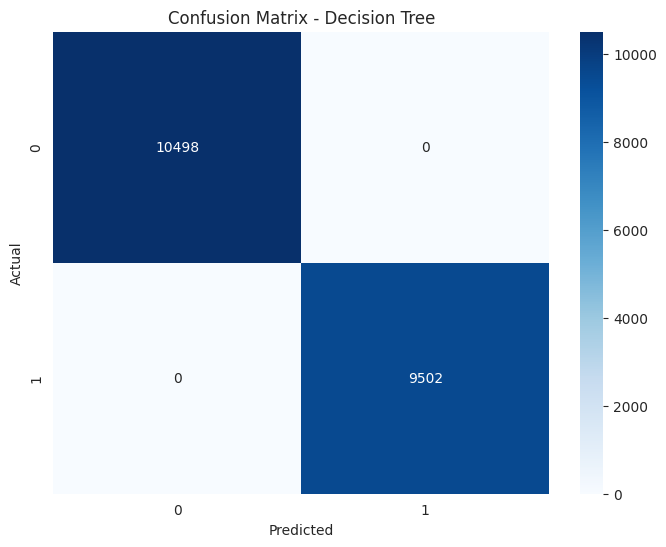

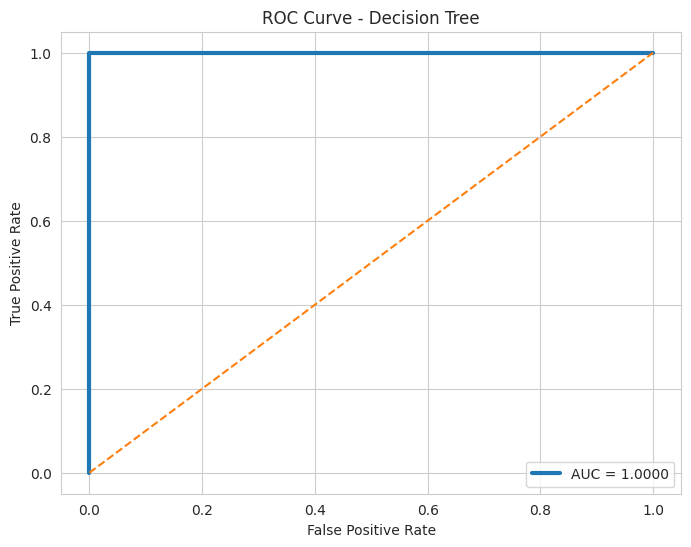


Top 20 Important Features
                             Feature  Importance
16                        fraud_risk    0.503621
8       failed_transaction_count_24h    0.143064
11               unusual_amount_flag    0.132916
14             high_risk_device_flag    0.047074
6          transaction_frequency_24h    0.045934
12             unusual_location_flag    0.045151
13  multiple_transactions_short_time    0.041274
10               previous_fraud_flag    0.021456
5                   is_international    0.016087
15                     velocity_flag    0.003424
0                 transaction_amount    0.000000
2                        device_type    0.000000
1                     payment_method    0.000000
4                  merchant_category    0.000000
3                           location    0.000000
9                   account_age_days    0.000000
7          avg_transaction_amount_7d    0.000000
17                  transaction_hour    0.000000
18                   transaction_day    0.

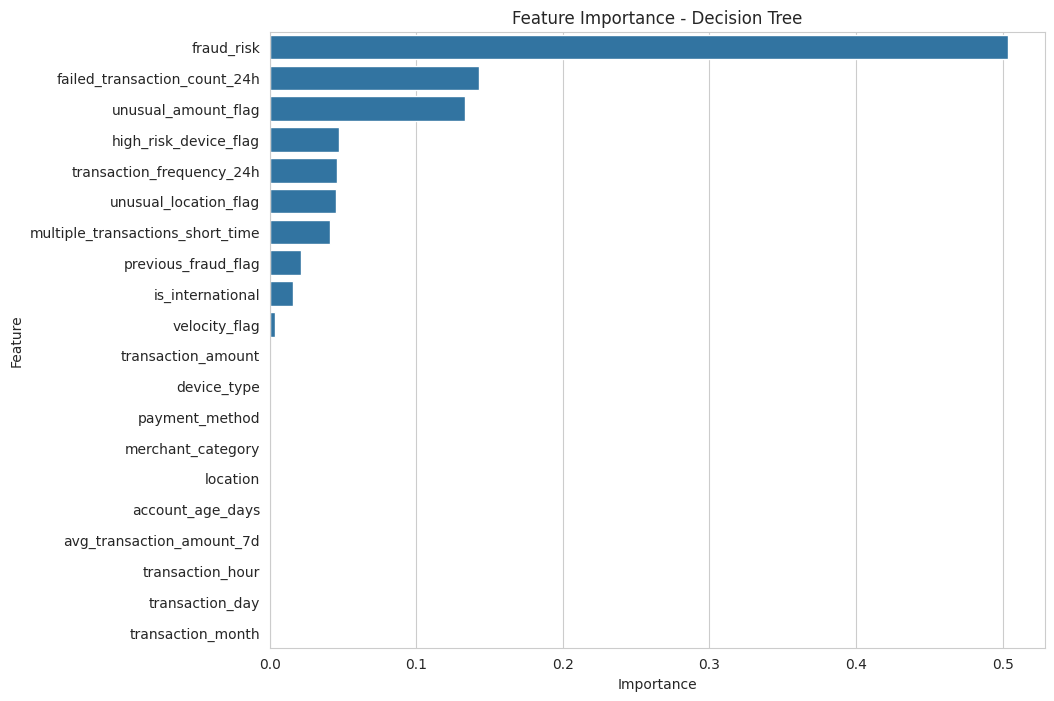



FINAL PERFORMANCE
Best Model : Decision Tree
Accuracy   : 100.0 %
ROC AUC    : 1.0


In [13]:
# ==========================================================
# FRAUD DETECTION - COMPLETE MACHINE LEARNING PIPELINE
# ==========================================================
# Features:
# ✔ Data Cleaning
# ✔ Proper Train-Test Split (No Data Leakage)
# ✔ Label Encoding AFTER Split
# ✔ Feature Engineering
# ✔ Multiple ML Algorithms
# ✔ Accuracy Comparison
# ✔ Classification Report
# ✔ Confusion Matrix
# ✔ ROC Curve
# ✔ ROC-AUC Score
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier
)

from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# ==========================================================
# DATASET COPY
# ==========================================================

data = df.copy()

print("="*60)
print("DATASET SHAPE")
print(data.shape)

print("\nTARGET DISTRIBUTION")
print(data['fraud_flag'].value_counts())

# ==========================================================
# DROP ID COLUMNS (NOT USEFUL FOR LEARNING)
# ==========================================================

drop_cols = [
    'transaction_id',
    'customer_id'
]

for col in drop_cols:
    if col in data.columns:
        data.drop(col, axis=1, inplace=True)

# ==========================================================
# HANDLE DATETIME COLUMN
# ==========================================================

if 'transaction_timestamp' in data.columns:

    data['transaction_timestamp'] = pd.to_datetime(
        data['transaction_timestamp'],
        errors='coerce'
    )

    data['transaction_hour'] = data['transaction_timestamp'].dt.hour
    data['transaction_day'] = data['transaction_timestamp'].dt.day
    data['transaction_month'] = data['transaction_timestamp'].dt.month
    data['transaction_weekday'] = data['transaction_timestamp'].dt.weekday

    data.drop(
        'transaction_timestamp',
        axis=1,
        inplace=True
    )

# ==========================================================
# TARGET
# ==========================================================

TARGET = 'fraud_flag'

X = data.drop(TARGET, axis=1)
y = data[TARGET]

# ==========================================================
# TRAIN TEST SPLIT FIRST
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTrain Shape:", X_train.shape)
print("Test Shape :", X_test.shape)

# ==========================================================
# LABEL ENCODING (NO DATA LEAKAGE)
# ==========================================================

categorical_cols = X_train.select_dtypes(
    include=['object']
).columns

encoders = {}

for col in categorical_cols:

    le = LabelEncoder()

    X_train[col] = le.fit_transform(
        X_train[col].astype(str)
    )

    mapping = {
        k:v
        for k,v in zip(
            le.classes_,
            le.transform(le.classes_)
        )
    }

    X_test[col] = X_test[col].astype(str)

    X_test[col] = X_test[col].map(mapping)

    X_test[col] = X_test[col].fillna(-1)

    encoders[col] = le

# ==========================================================
# HANDLE MISSING VALUES
# ==========================================================

X_train = X_train.fillna(X_train.median(numeric_only=True))
X_test = X_test.fillna(X_train.median(numeric_only=True))

# ==========================================================
# MODELS
# ==========================================================

models = {

    "Logistic Regression":
        LogisticRegression(max_iter=500),

    "Decision Tree":
        DecisionTreeClassifier(
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            random_state=42
        ),

    "Extra Trees":
        ExtraTreesClassifier(
            n_estimators=200,
            random_state=42
        ),

    "Naive Bayes":
        GaussianNB(),

    "KNN":
        KNeighborsClassifier(
            n_neighbors=5
        )
}

# ==========================================================
# TRAIN MODELS
# ==========================================================

results = []

best_model = None
best_auc = 0

print("\n")
print("="*80)
print("MODEL TRAINING")
print("="*80)

for name, model in models.items():

    print(f"\n{name}")

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    if hasattr(model, "predict_proba"):

        y_prob = model.predict_proba(X_test)[:,1]

        auc_score = roc_auc_score(
            y_test,
            y_prob
        )

    else:

        auc_score = 0

    results.append([
        name,
        accuracy,
        auc_score
    ])

    print(f"Accuracy : {accuracy:.4f}")
    print(f"ROC AUC  : {auc_score:.4f}")

    if auc_score > best_auc:

        best_auc = auc_score
        best_model = model
        best_name = name

# ==========================================================
# RESULTS TABLE
# ==========================================================

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "ROC_AUC"
    ]
)

results_df = results_df.sort_values(
    by="ROC_AUC",
    ascending=False
)

print("\n")
print("="*80)
print("MODEL COMPARISON")
print("="*80)

print(results_df)

# ==========================================================
# BEST MODEL EVALUATION
# ==========================================================

print("\n")
print("="*80)
print("BEST MODEL")
print("="*80)

print(best_name)

y_pred = best_model.predict(X_test)

y_prob = best_model.predict_proba(
    X_test
)[:,1]

# ==========================================================
# CLASSIFICATION REPORT
# ==========================================================

print("\nClassification Report")

print(
    classification_report(
        y_test,
        y_pred
    )
)

# ==========================================================
# CONFUSION MATRIX
# ==========================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    f'Confusion Matrix - {best_name}'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ==========================================================
# ROC CURVE
# ==========================================================

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    linewidth=3,
    label=f'AUC = {roc_auc:.4f}'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    f'ROC Curve - {best_name}'
)

plt.legend()

plt.show()

# ==========================================================
# FEATURE IMPORTANCE
# ==========================================================

if hasattr(best_model, "feature_importances_"):

    importance = pd.DataFrame({

        "Feature":
            X_train.columns,

        "Importance":
            best_model.feature_importances_
    })

    importance = importance.sort_values(
        by="Importance",
        ascending=False
    )

    print("\nTop 20 Important Features")

    print(
        importance.head(20)
    )

    plt.figure(figsize=(10,8))

    sns.barplot(
        data=importance.head(20),
        x="Importance",
        y="Feature"
    )

    plt.title(
        f'Feature Importance - {best_name}'
    )

    plt.show()

# ==========================================================
# FINAL METRICS
# ==========================================================

final_accuracy = accuracy_score(
    y_test,
    y_pred
)

final_auc = roc_auc_score(
    y_test,
    y_prob
)

print("\n")
print("="*80)
print("FINAL PERFORMANCE")
print("="*80)

print("Best Model :", best_name)
print("Accuracy   :", round(final_accuracy*100,2), "%")
print("ROC AUC    :", round(final_auc,4))
print("="*80)

## Thanks............Please Upvotes